# Project X -- Vinay Gannamaneni

**TA Help:** (for instance) John Smith, Alice Jones, etc., list names of any TAs who helped you

- For example: Help with figuring out how to write a function (describe the tasks that they helped you with)

**Collaboration:** My Friend in CS, My Uncle, Another Student, etc., list names of any other people who helped you

(describe the tasks that they helped you with)
- For example: helped figuring out how to load the dataset.
- Another example: helped debug error with my plot.

**Internet Resources:** Stack Exchange, Stack Overflow, etc.

(describe any information that you learned from internet resources, including the URLs)
- data frames in Pandas versus R from StackOverflow  https://stackoverflow.com/questions/8991709/why-were-pandas-merges-in-python-faster-than-data-table-merges-in-r-in-2012

**ChatGPT, Gemini, Claude, etc:** Any language models or generative AI chatbots that helped you.

(if you used any such tools, please tell us here)
- For example:  I asked ChatGPT how to define a new data frames
- Another example:  Gemini told me how to make a function for sorting my data

- ***Link to AI Chat History***: Please share a link to your chat if you used AI (ex. ChatGPT Shared Links)
**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [2]:
library(ggplot2)
library(dplyr)
names_2006 <- read.table("/anvil/projects/tdm/data/ssa/yob2006.txt", sep = ",", header = FALSE)
names_1997 <- read.table("/anvil/projects/tdm/data/ssa/yob1997.txt", sep = ",", header = FALSE)
colnames(names_2006) <- c("Name", "Sex", "Counts")
colnames(names_1997) <- c("Name", "Sex", "Counts")

Read in data sets and add proper colum names

In [4]:
selected_2006 <- names_2006 %>% filter(Name %in% c("Alan", "Eric", "Avery"))
selected_1997 <- names_1997 %>% filter(Name %in% c("Alan", "Eric", "Avery"))

Subset for Alan, Eric, and Avery in 1997 and 2006 and print the results

In [5]:
selected_2006
selected_1997

Name,Sex,Counts
<chr>,<chr>,<int>
Avery,F,5254
Eric,F,11
Alan,F,6
Eric,M,6231
Alan,M,3475
Avery,M,1794


Name,Sex,Counts
<chr>,<chr>,<int>
Avery,F,937
Eric,F,37
Alan,F,7
Eric,M,10317
Alan,M,2177
Avery,M,1173


Observation:
- Avery (F) increased from 937 in 1997 → 5254 in 2006
- Eric (M) decreased from 10317 → 6231
- Alan (M) increased from 2177 → 3475
- Female Eric and Alan remain very rare
- Avery (M) had a small increase from 1173 → 1794

In [6]:
top20_1997 <- names_1997 %>%
  group_by(Name) %>%
  summarise(Total = sum(Counts)) %>%
  arrange(desc(Total)) %>%
  slice(1:20)

top20_2006 <- names_2006 %>%
  group_by(Name) %>%
  summarise(Total = sum(Counts)) %>%
  arrange(desc(Total)) %>%
  slice(1:20)

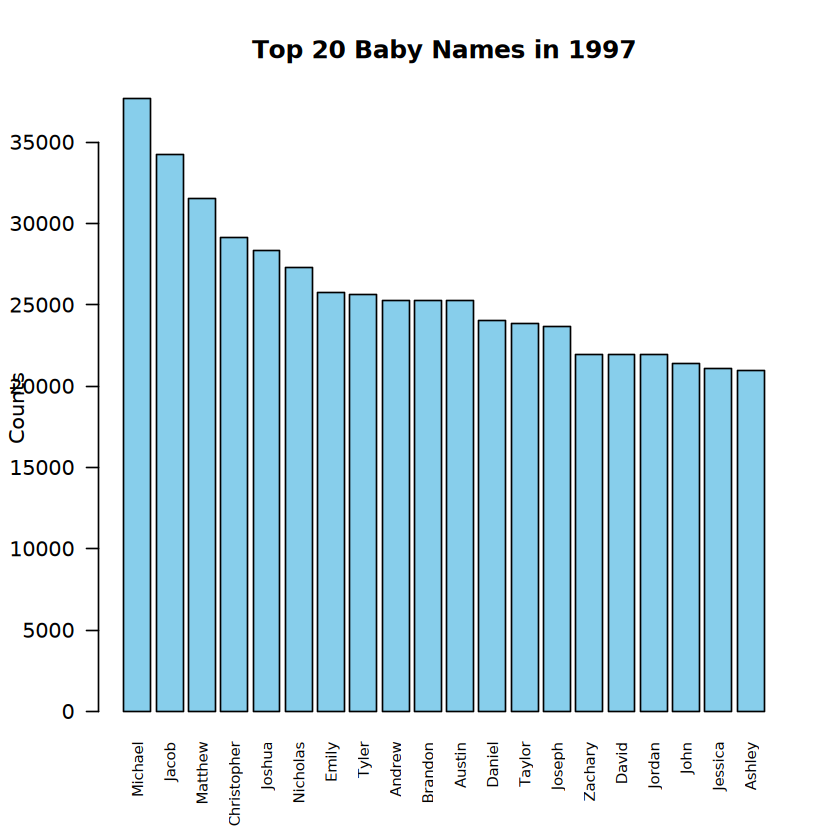

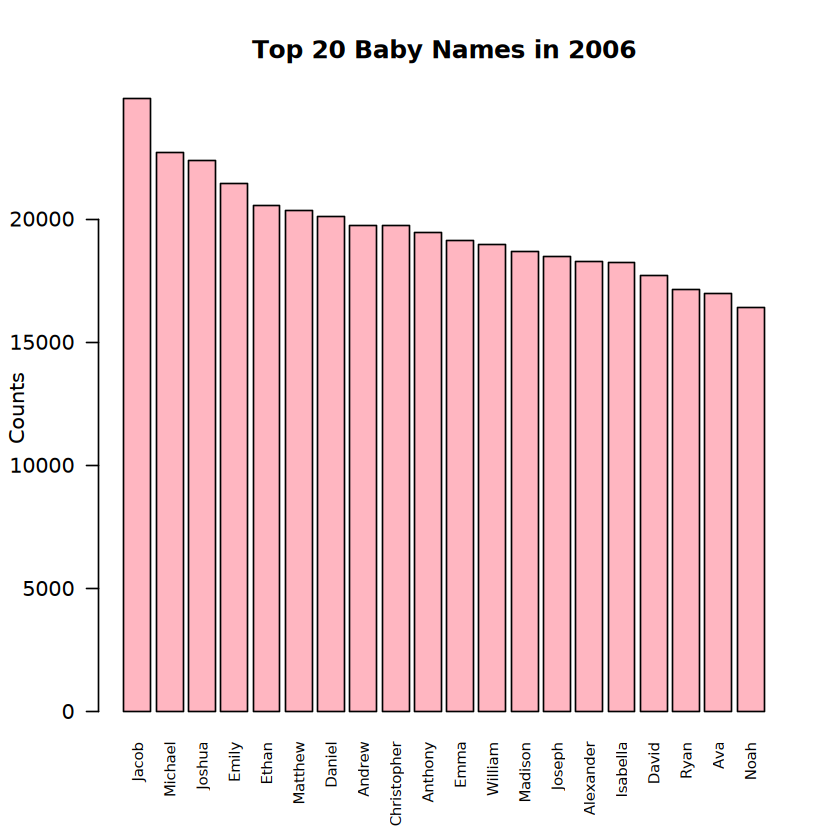

In [11]:
# Base R barplot 1997
barplot(top20_1997$Total, names.arg = top20_1997$Name, las=2, col="skyblue",
        main="Top 20 Baby Names in 1997", ylab="Counts", cex.names=0.7)

# Base R barplot 2006
barplot(top20_2006$Total, names.arg = top20_2006$Name, las=2, col="lightpink",
        main="Top 20 Baby Names in 2006", ylab="Counts", cex.names=0.7)

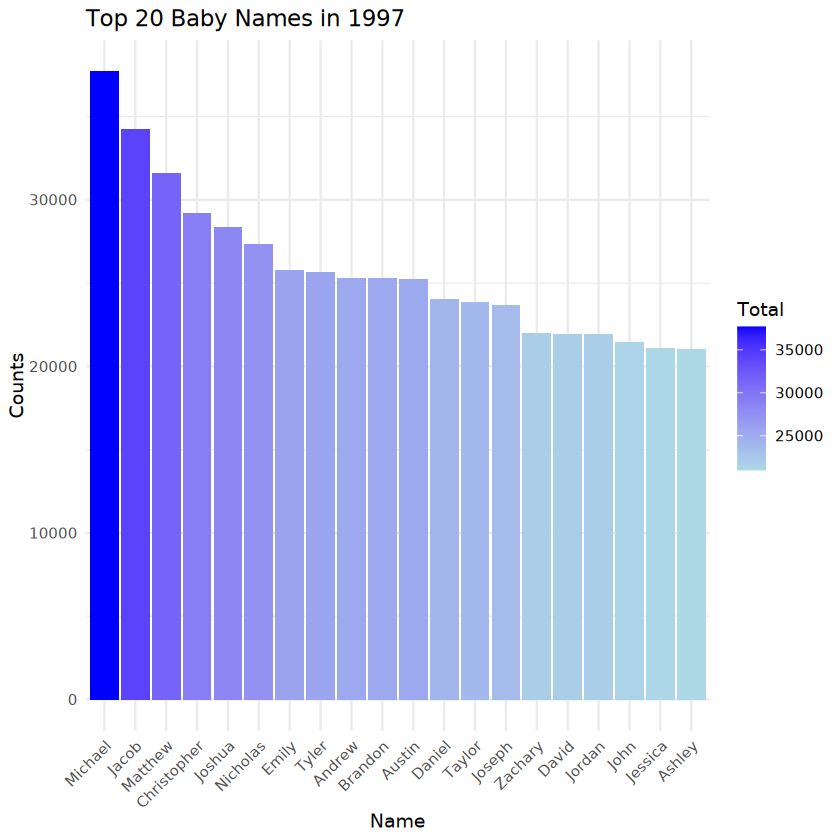

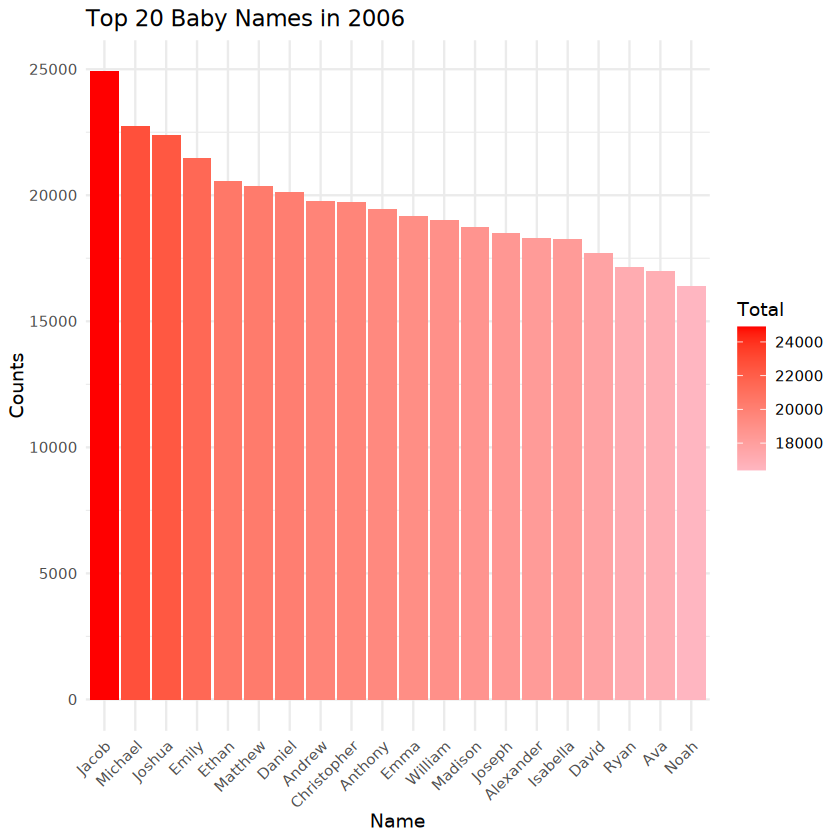

In [12]:
ggplot(top20_1997, aes(x = reorder(Name, -Total), y = Total, fill = Total)) +
  geom_bar(stat="identity") +
  labs(title="Top 20 Baby Names in 1997", x="Name", y="Counts") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=45, hjust=1)) +
  scale_fill_gradient(low="lightblue", high="blue")

ggplot(top20_2006, aes(x = reorder(Name, -Total), y = Total, fill = Total)) +
  geom_bar(stat="identity") +
  labs(title="Top 20 Baby Names in 2006", x="Name", y="Counts") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=45, hjust=1)) +
  scale_fill_gradient(low="lightpink", high="red")

ggplot2 Barplots (Top 20 Names)

- To begin working with ggplot2, I loaded the package and supplied the dataset along with aesthetic mappings (aes) for x- and y-axes. 
- I used geom_bar(stat="identity") to create barplots and customized them with rotated x-axis labels, gradient fill, and a clean minimal theme. 
- This made the barplots more visually appealing and easier to interpret compared to base R plots.

## Question 2

In [16]:

first_letter_counts <- names_2006 %>%

  mutate(first_letter = substr(Name, 1, 1)) %>%

  group_by(first_letter) %>%

  summarise(total_count = sum(Counts)) %>%
  arrange(first_letter)

Using the names_2006 dataset, create new column with first letter of each name. Then group by first letter and summarize total counts for each first letter

In [17]:
first_letter_counts

first_letter,total_count
<chr>,<int>
A,548710
B,174687
C,286526
D,208703
E,222850
F,33023
G,115702
H,94301
I,85057


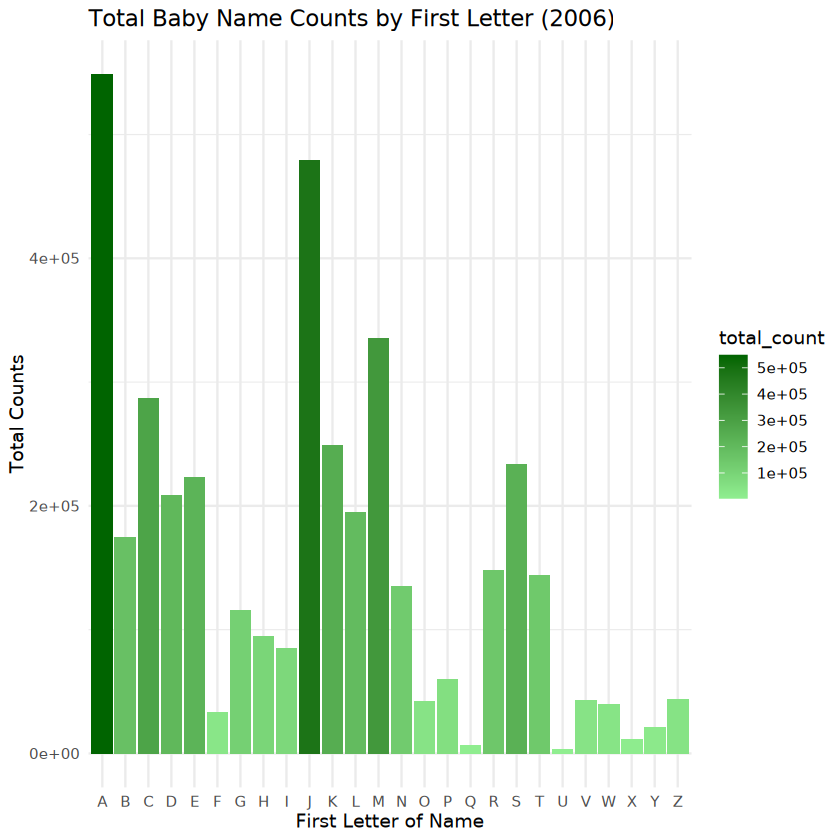

In [19]:
ggplot(first_letter_counts, aes(x = first_letter, y = total_count, fill = total_count)) +
  geom_col() +
  labs(title = "Total Baby Name Counts by First Letter (2006)",
       x = "First Letter of Name",
       y = "Total Counts") +
  theme_minimal() +
  scale_fill_gradient(low = "lightgreen", high = "darkgreen")

I chose geom_col() here because we already have pre-aggregated counts per first letter. geom_bar() would require ggplot2 to count the observations itself, which is unnecessary here.

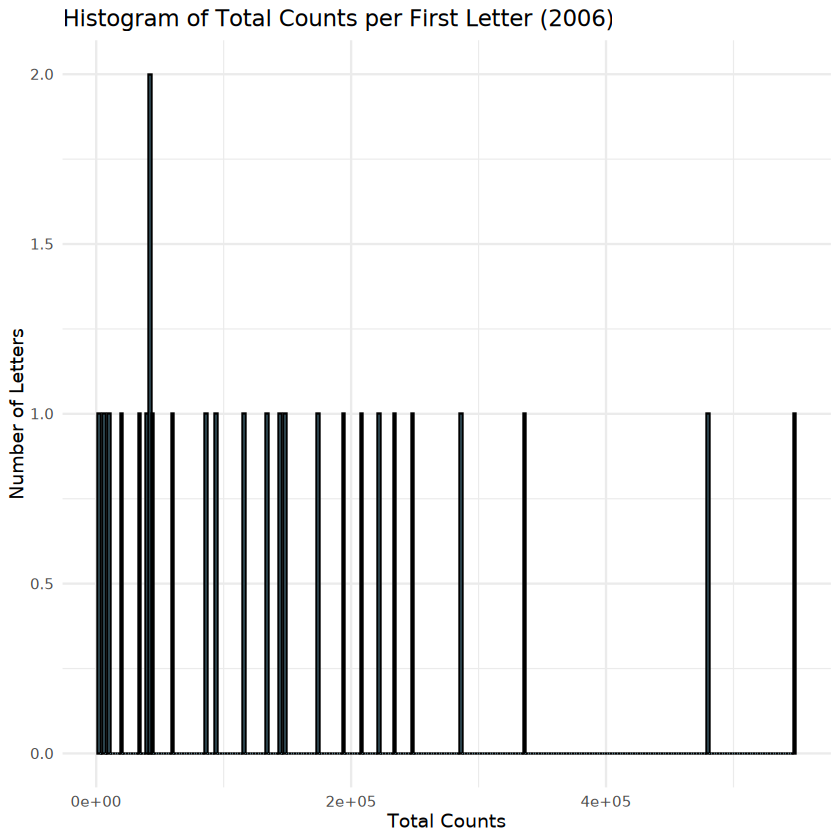

In [20]:
ggplot(first_letter_counts, aes(x = total_count)) +
  geom_histogram(binwidth = 2000, fill = "skyblue", color = "black") +
  labs(title = "Histogram of Total Counts per First Letter (2006)",
       x = "Total Counts",
       y = "Number of Letters") +
  theme_minimal()

This is not ideal for categorical letters, but demonstrates numeric distribution

Explanation:
- Using a histogram like this is not very useful because the x-axis is numeric (total counts) but the data represents letters (categorical).
- It shows how total counts are distributed, but we lose information about which letter corresponds to which count.
- Histograms are better suited for truly numeric variables where we want to see the shape or distribution of values across a large dataset.

## Question 3

In [21]:
names_2006_grouped <- names_2006 %>%

  mutate(first_letter = substr(Name, 1, 1)) %>%

  group_by(first_letter, Sex) %>%

  summarise(total_count = sum(Counts), .groups = 'drop')

Create first_letter column and group by first_letter and sex. Then sum counts for each group

In [22]:
names_2006_grouped

first_letter,Sex,total_count
<chr>,<chr>,<int>
A,F,323402
A,M,225308
B,F,66220
B,M,108467
C,F,106794
C,M,179732
D,F,58620
D,M,150083
E,F,121623


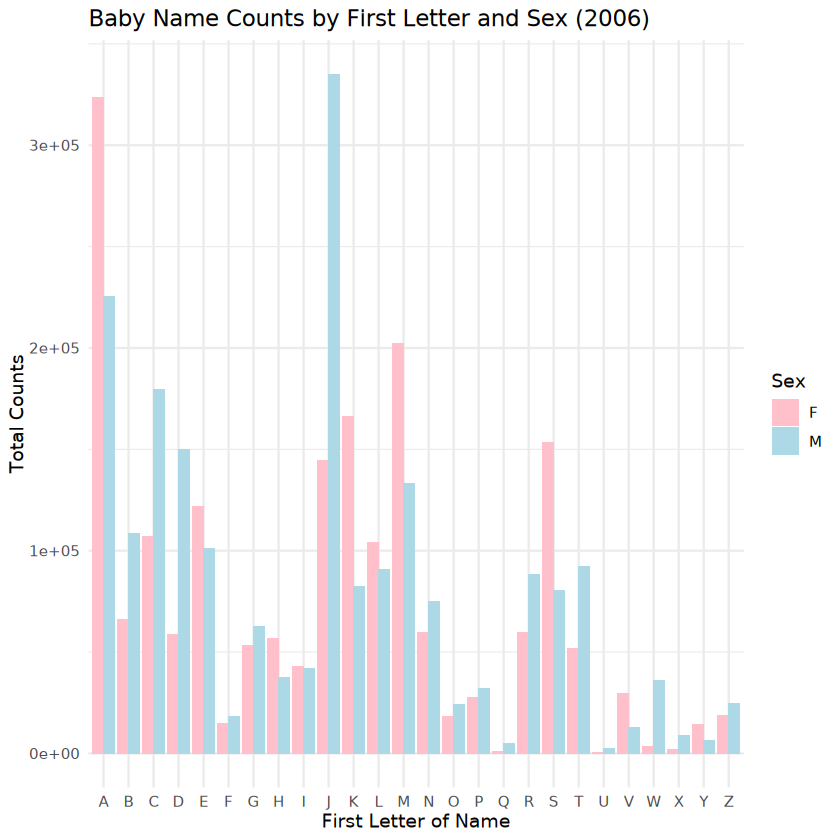

In [24]:
ggplot(names_2006_grouped, aes(x = first_letter, y = total_count, fill = Sex)) +
  geom_col(position = "dodge") +   # side-by-side bars for male and female
  labs(title = "Baby Name Counts by First Letter and Sex (2006)",
       x = "First Letter of Name",
       y = "Total Counts") +
  theme_minimal() +
  scale_fill_manual(values = c("F" = "pink", "M" = "lightblue"))

Barplot colored by Sex

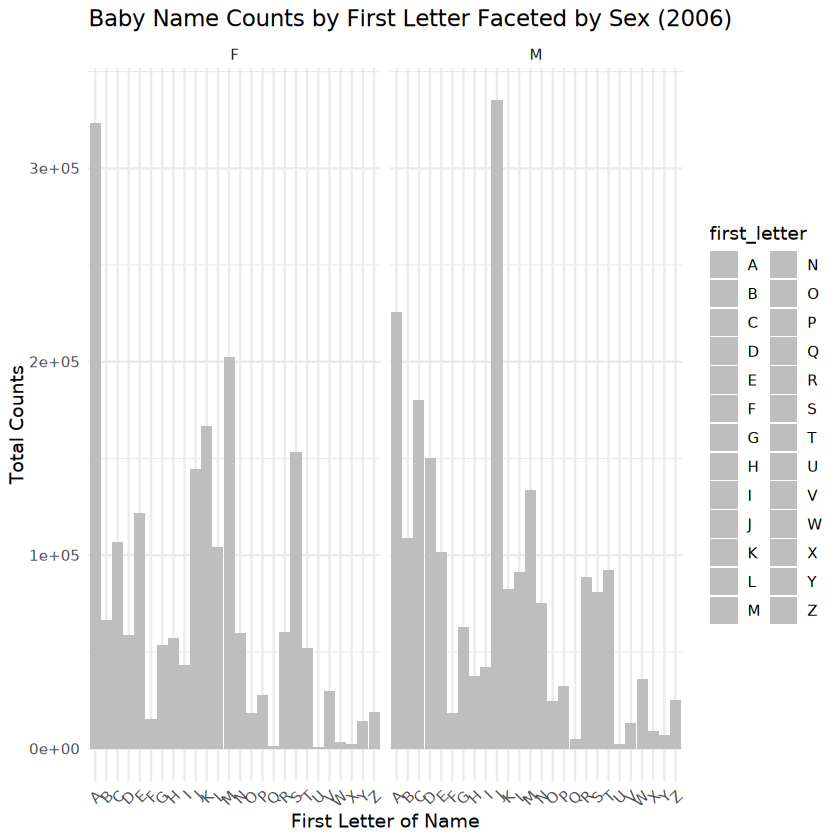

In [25]:
ggplot(names_2006_grouped, aes(x = first_letter, y = total_count, fill = first_letter)) +
  geom_col() +
  facet_wrap(~Sex) +
  labs(title = "Baby Name Counts by First Letter Faceted by Sex (2006)",
       x = "First Letter of Name",
       y = "Total Counts") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=45, hjust=1)) +
  scale_fill_manual(values = rep("gray", 26)) 

In [37]:
highlight_colors <- c(
  "A" = "maroon",
  "E" = "lightgreen",
  "S" = "navyblue"
)

all_letters <- unique(names_2006_grouped$first_letter)
for (letter in all_letters) {
  if (!letter %in% names(highlight_colors)) highlight_colors[letter] <- "gray"
}

Define highlight colors for letters A, E, S and all other letters will be gray

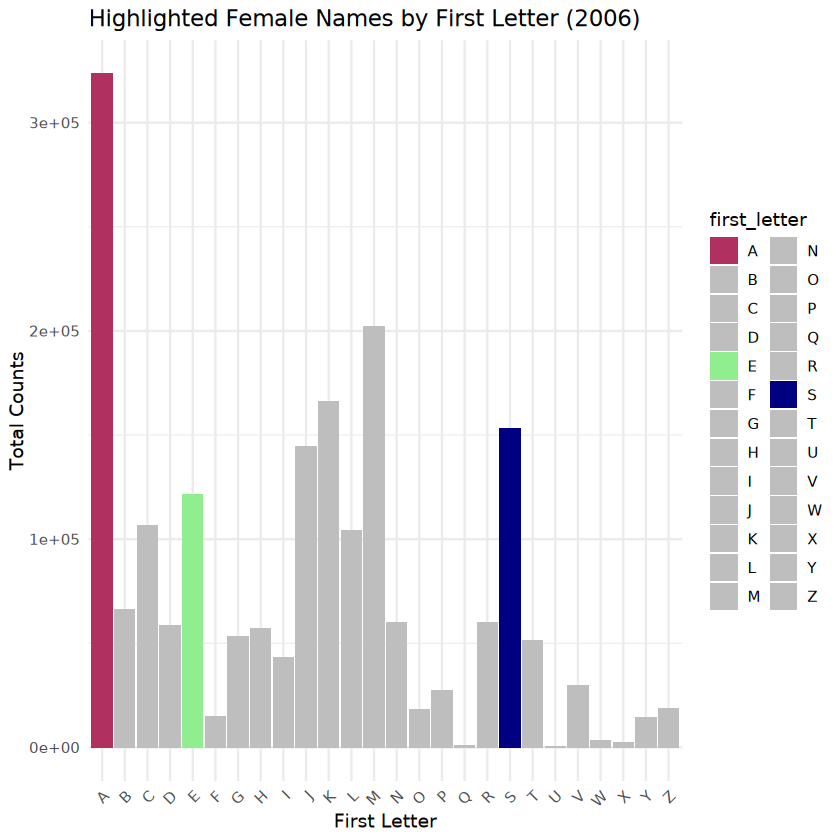

In [38]:
ggplot(names_2006_grouped %>% filter(Sex == "F"), 
       aes(x = first_letter, y = total_count, fill = first_letter)) +
  geom_col() +
  labs(title = "Highlighted Female Names by First Letter (2006)",
       x = "First Letter",
       y = "Total Counts") +

  theme_minimal() +
  theme(axis.text.x = element_text(angle=45, hjust=1)) +
  scale_fill_manual(values = highlight_colors)

Create a barplot highlighting specific letters for Female names

## Question 4

In [41]:
library(patchwork)
zillow <- read.csv("/anvil/projects/tdm/data/zillow/State_time_series.csv")
head(zillow)

,Date,RegionName,DaysOnZillow_AllHomes,InventorySeasonallyAdjusted_AllHomes,InventoryRaw_AllHomes,MedianListingPricePerSqft_1Bedroom,MedianListingPricePerSqft_2Bedroom,MedianListingPricePerSqft_3Bedroom,MedianListingPricePerSqft_4Bedroom,MedianListingPricePerSqft_5BedroomOrMore,...,ZHVI_BottomTier,ZHVI_CondoCoop,ZHVI_MiddleTier,ZHVI_SingleFamilyResidence,ZHVI_TopTier,ZRI_AllHomes,ZRI_AllHomesPlusMultifamily,ZriPerSqft_AllHomes,Zri_MultiFamilyResidenceRental,Zri_SingleFamilyResidenceRental
,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>
1,1996-04-30,Alabama,NA,NA,NA,NA,NA,NA,NA,NA,...,45600,99500,79500,79000,140200,NA,NA,NA,NA,NA
2,1996-04-30,Arizona,NA,NA,NA,NA,NA,NA,NA,NA,...,67100,78900,103600,107500,168700,NA,NA,NA,NA,NA
3,1996-04-30,Arkansas,NA,NA,NA,NA,NA,NA,NA,NA,...,38400,70300,64400,64500,115200,NA,NA,NA,NA,NA
4,1996-04-30,California,NA,NA,NA,NA,NA,NA,NA,NA,...,95100,136100,157900,162000,270600,NA,NA,NA,NA,NA
5,1996-04-30,Colorado,NA,NA,NA,NA,NA,NA,NA,NA,...,82700,99400,128100,133600,209300,NA,NA,NA,NA,NA
6,1996-04-30,Connecticut,NA,NA,NA,NA,NA,NA,NA,NA,...,83700,85000,132000,141000,231600,NA,NA,NA,NA,NA


In [44]:
zillow_cleaned <- zillow %>%
  filter(!is.na(DaysOnZillow_AllHomes),
         !is.na(MedianListingPrice_AllHomes))

sum(is.na(zillow_cleaned$DaysOnZillow_AllHomes))   # Should be 0
sum(is.na(zillow_cleaned$MedianListingPrice_AllHomes)) # Should be 0

[1] 0

[1] 0

To clean the data, remove rows with NA in key columns and verify

Explanation:
- Missing data in ggplot2 leads to gray points because ggplot cannot map NA values to colors.
- By filtering out NA values, we remove incomplete data and all points can be properly colored and displayed.

In [45]:
options(repr.plot.width = 20, repr.plot.height = 16)

p1 <- ggplot(zillow_cleaned, aes(
  x = DaysOnZillow_AllHomes,
  y = MedianListingPrice_AllHomes,
  color = PctOfHomesDecreasingInValues_AllHomes
)) +
  geom_point(size = 3, shape = 2) +  # Shape 2 = triangle
  scale_color_gradient(low = "blue", high = "red") +  # Gradient: blue = low, red = high
  geom_smooth(method = "lm", se = FALSE, color = "black") + # Add linear trendline
  labs(title = "Scatterplot of Days on Zillow vs Median Listing Price (Decreasing Values)",
       x = "Days on Zillow (All Homes)",
       y = "Median Listing Price (All Homes)",
       color = "% Homes Decreasing in Value") +
  theme_minimal()

Scatterplot with PctOfHomesDecreasingInValues_AllHomes

`geom_smooth()` using formula = 'y ~ x'


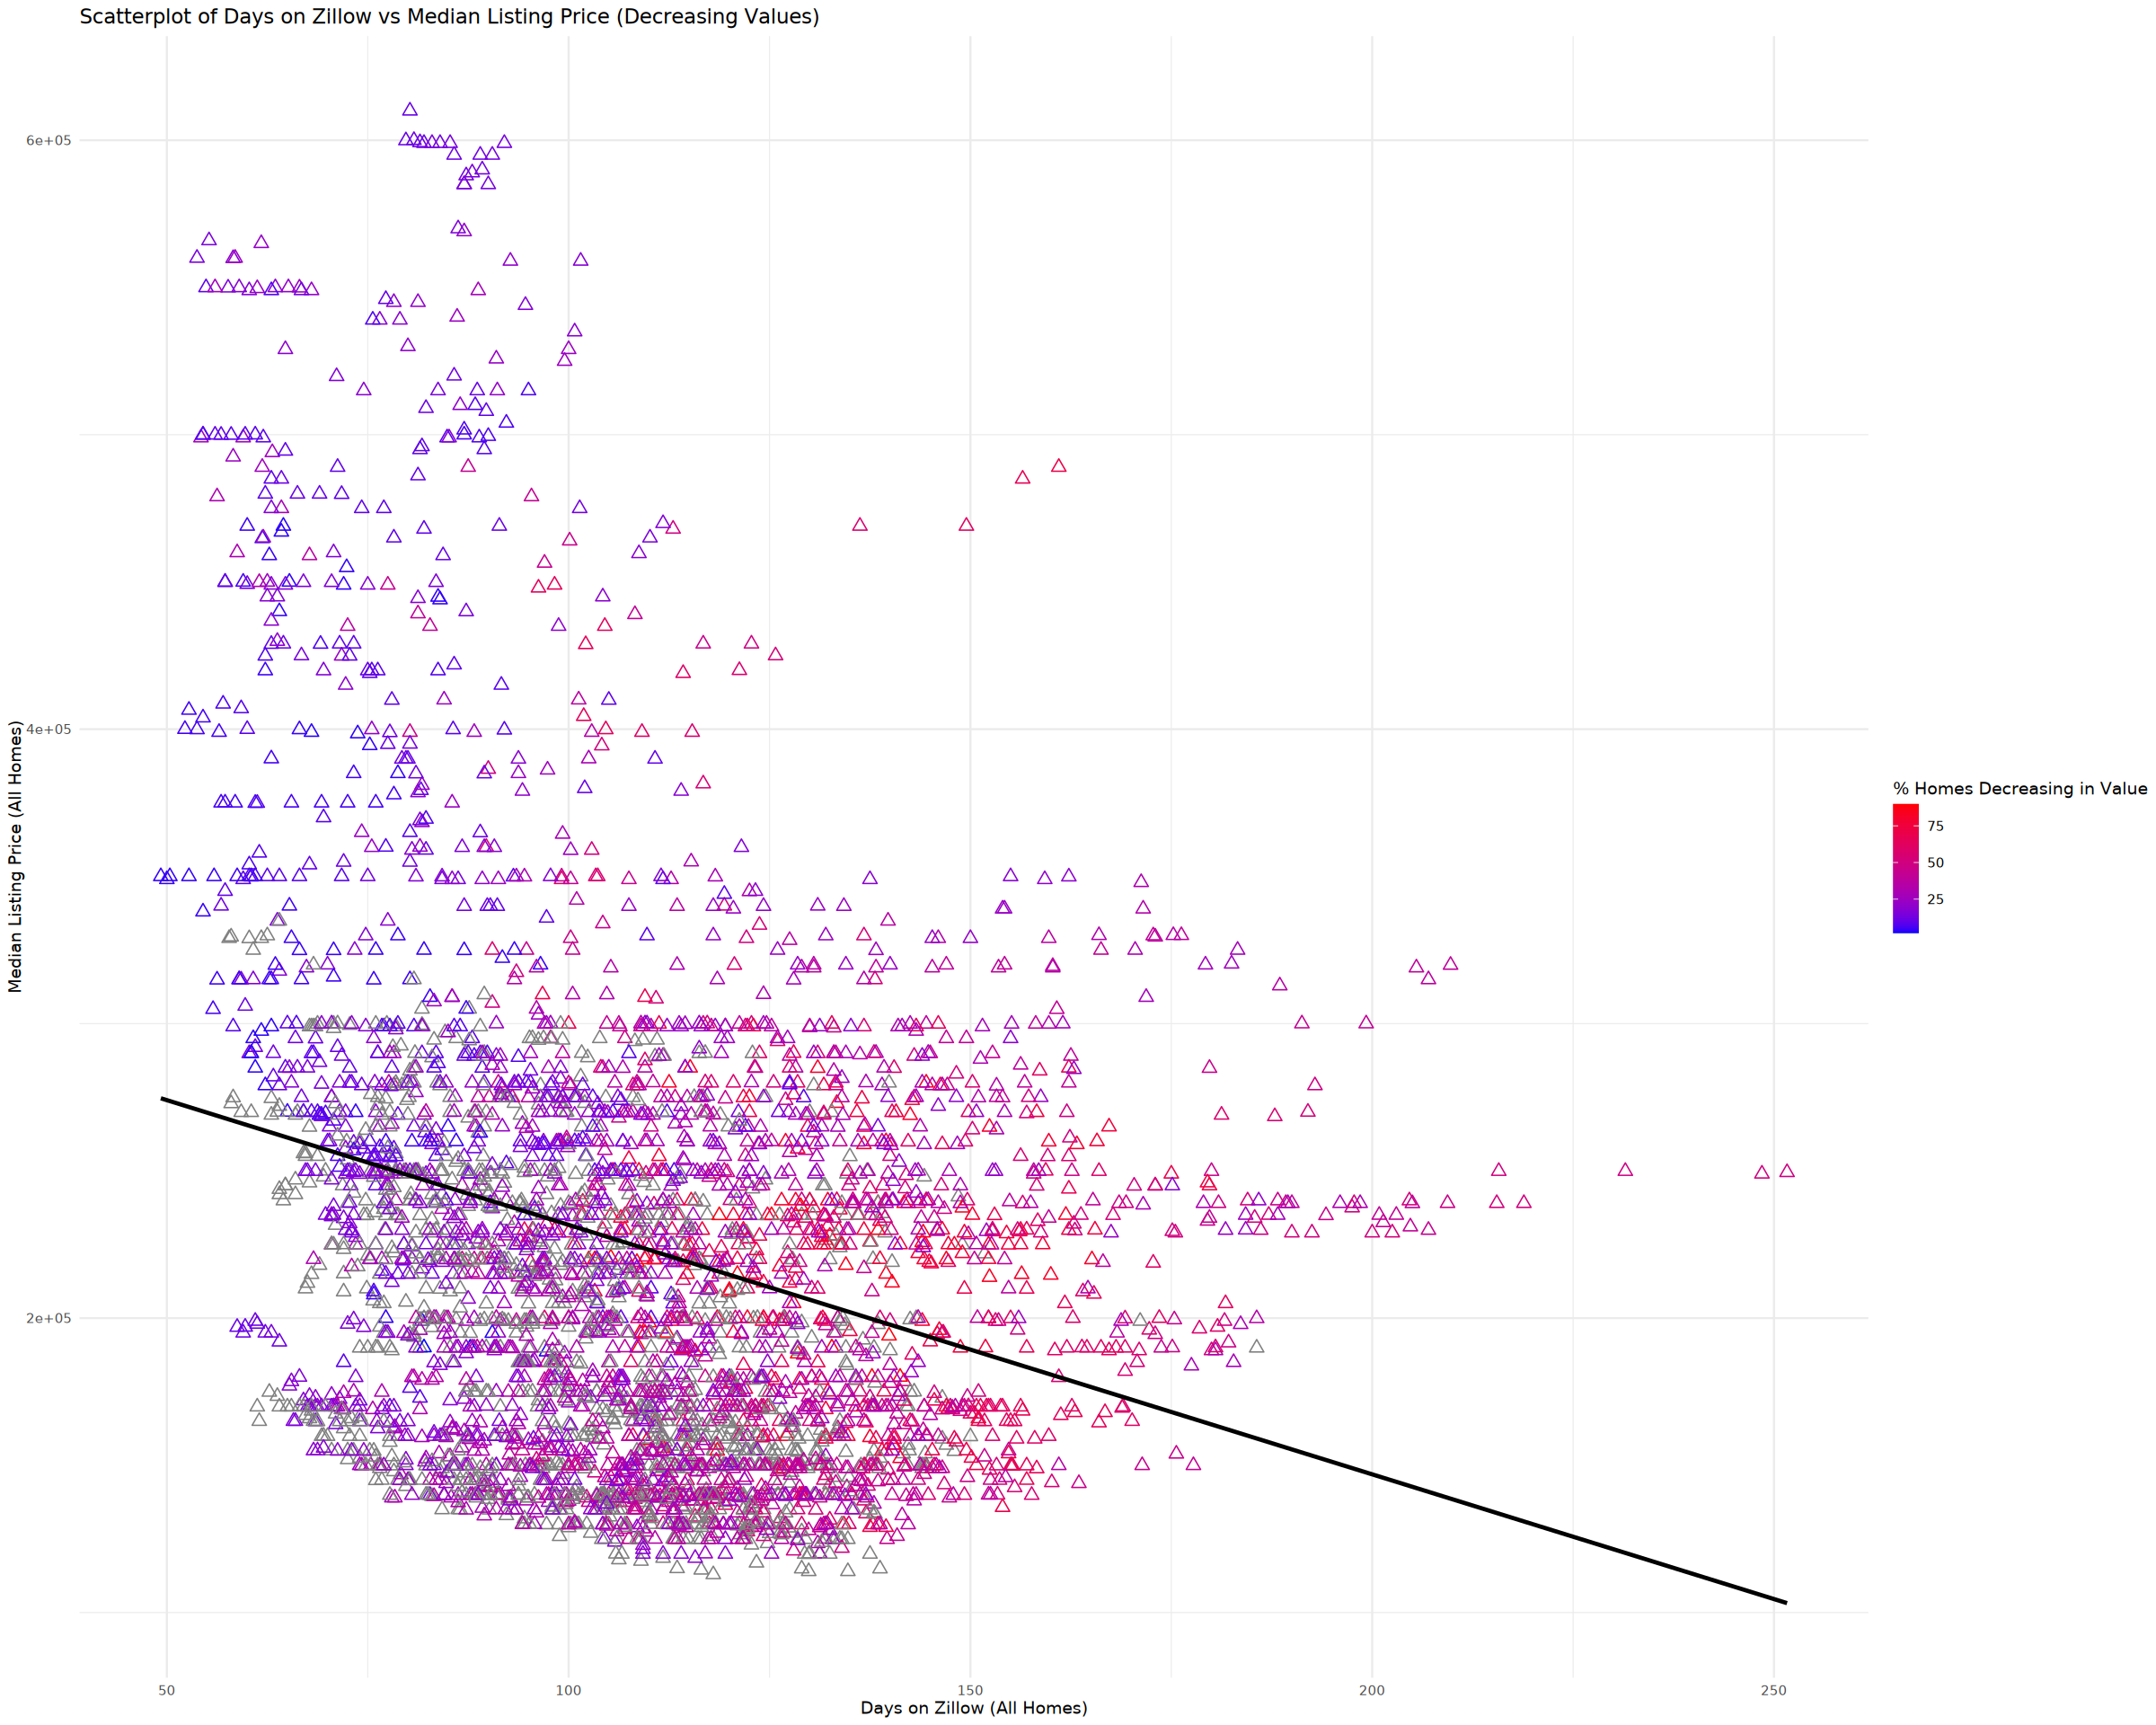

In [46]:
p1

In [47]:
p2 <- ggplot(zillow_cleaned, aes(
  x = DaysOnZillow_AllHomes,
  y = MedianListingPrice_AllHomes,
  color = PctOfHomesIncreasingInValues_AllHomes
)) +
  geom_point(size = 3, shape = 2) +
  scale_color_gradient(low = "blue", high = "red") +
  geom_smooth(method = "lm", se = FALSE, color = "black") +
  labs(title = "Scatterplot of Days on Zillow vs Median Listing Price (Increasing Values)",
       x = "Days on Zillow (All Homes)",
       y = "Median Listing Price (All Homes)",
       color = "% Homes Increasing in Value") +
  theme_minimal()

Scatterplot with PctOfHomesIncreasingInValues_AllHomes

`geom_smooth()` using formula = 'y ~ x'


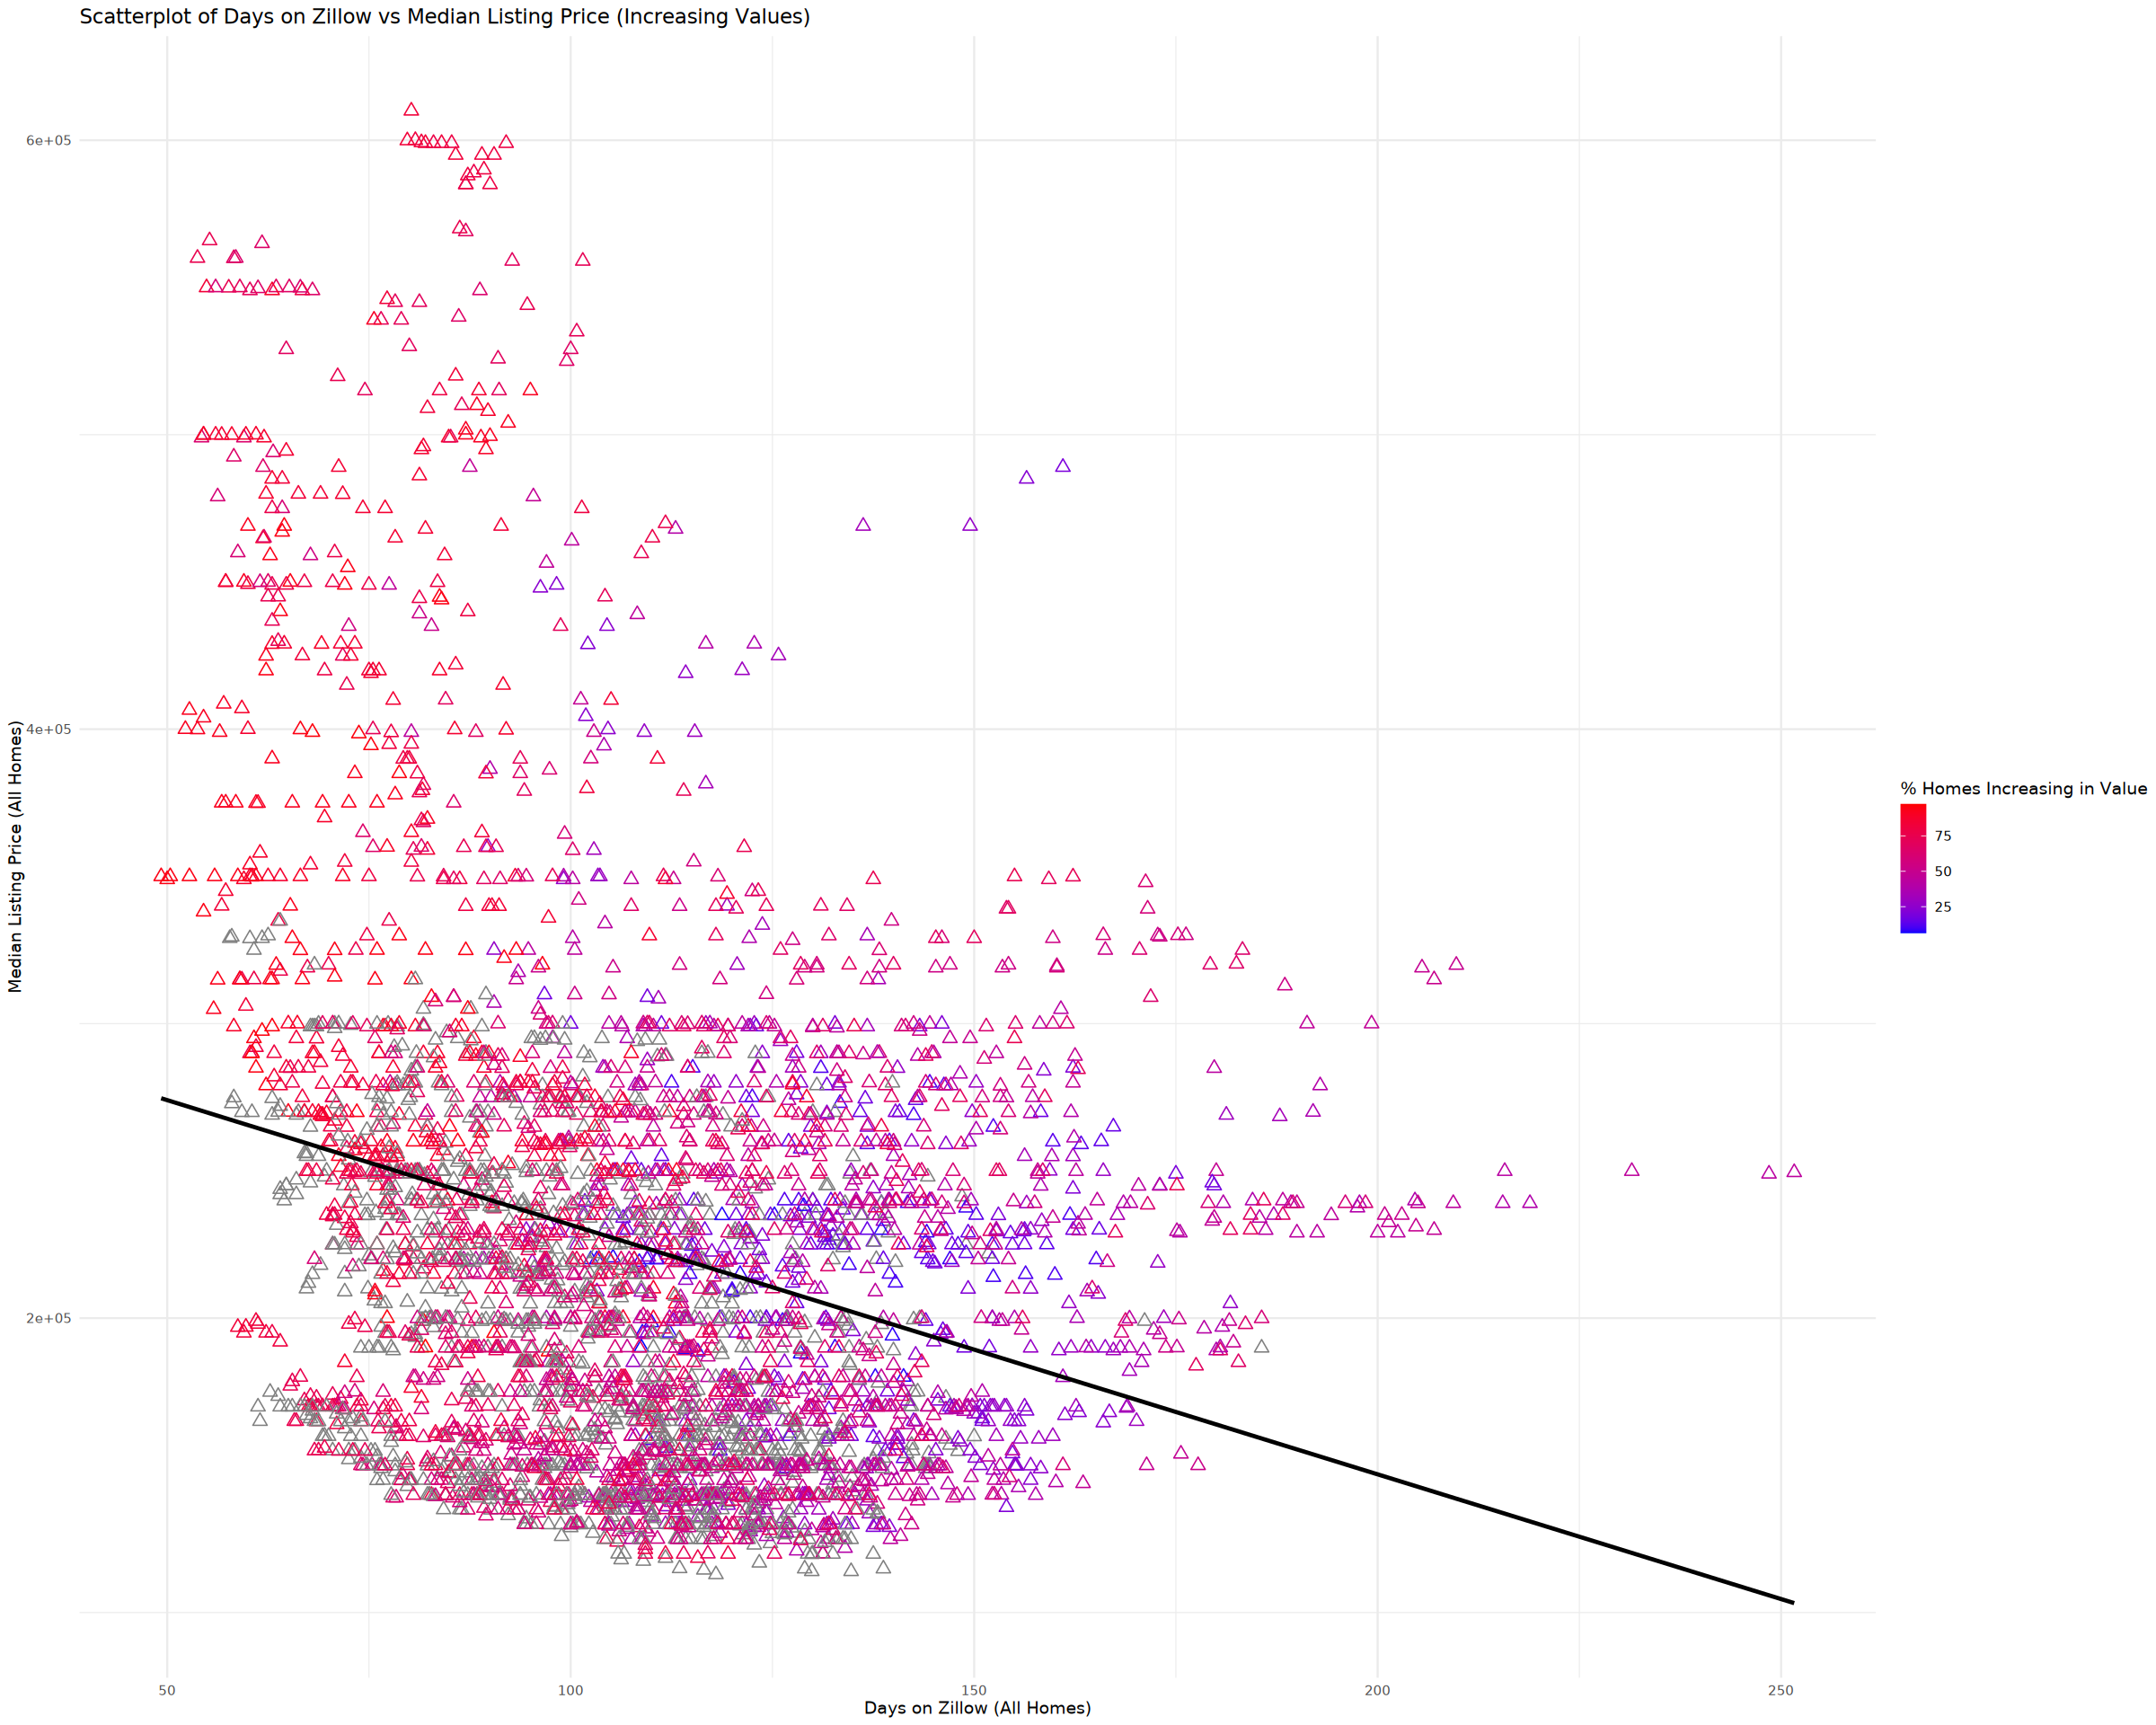

In [48]:
p2

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


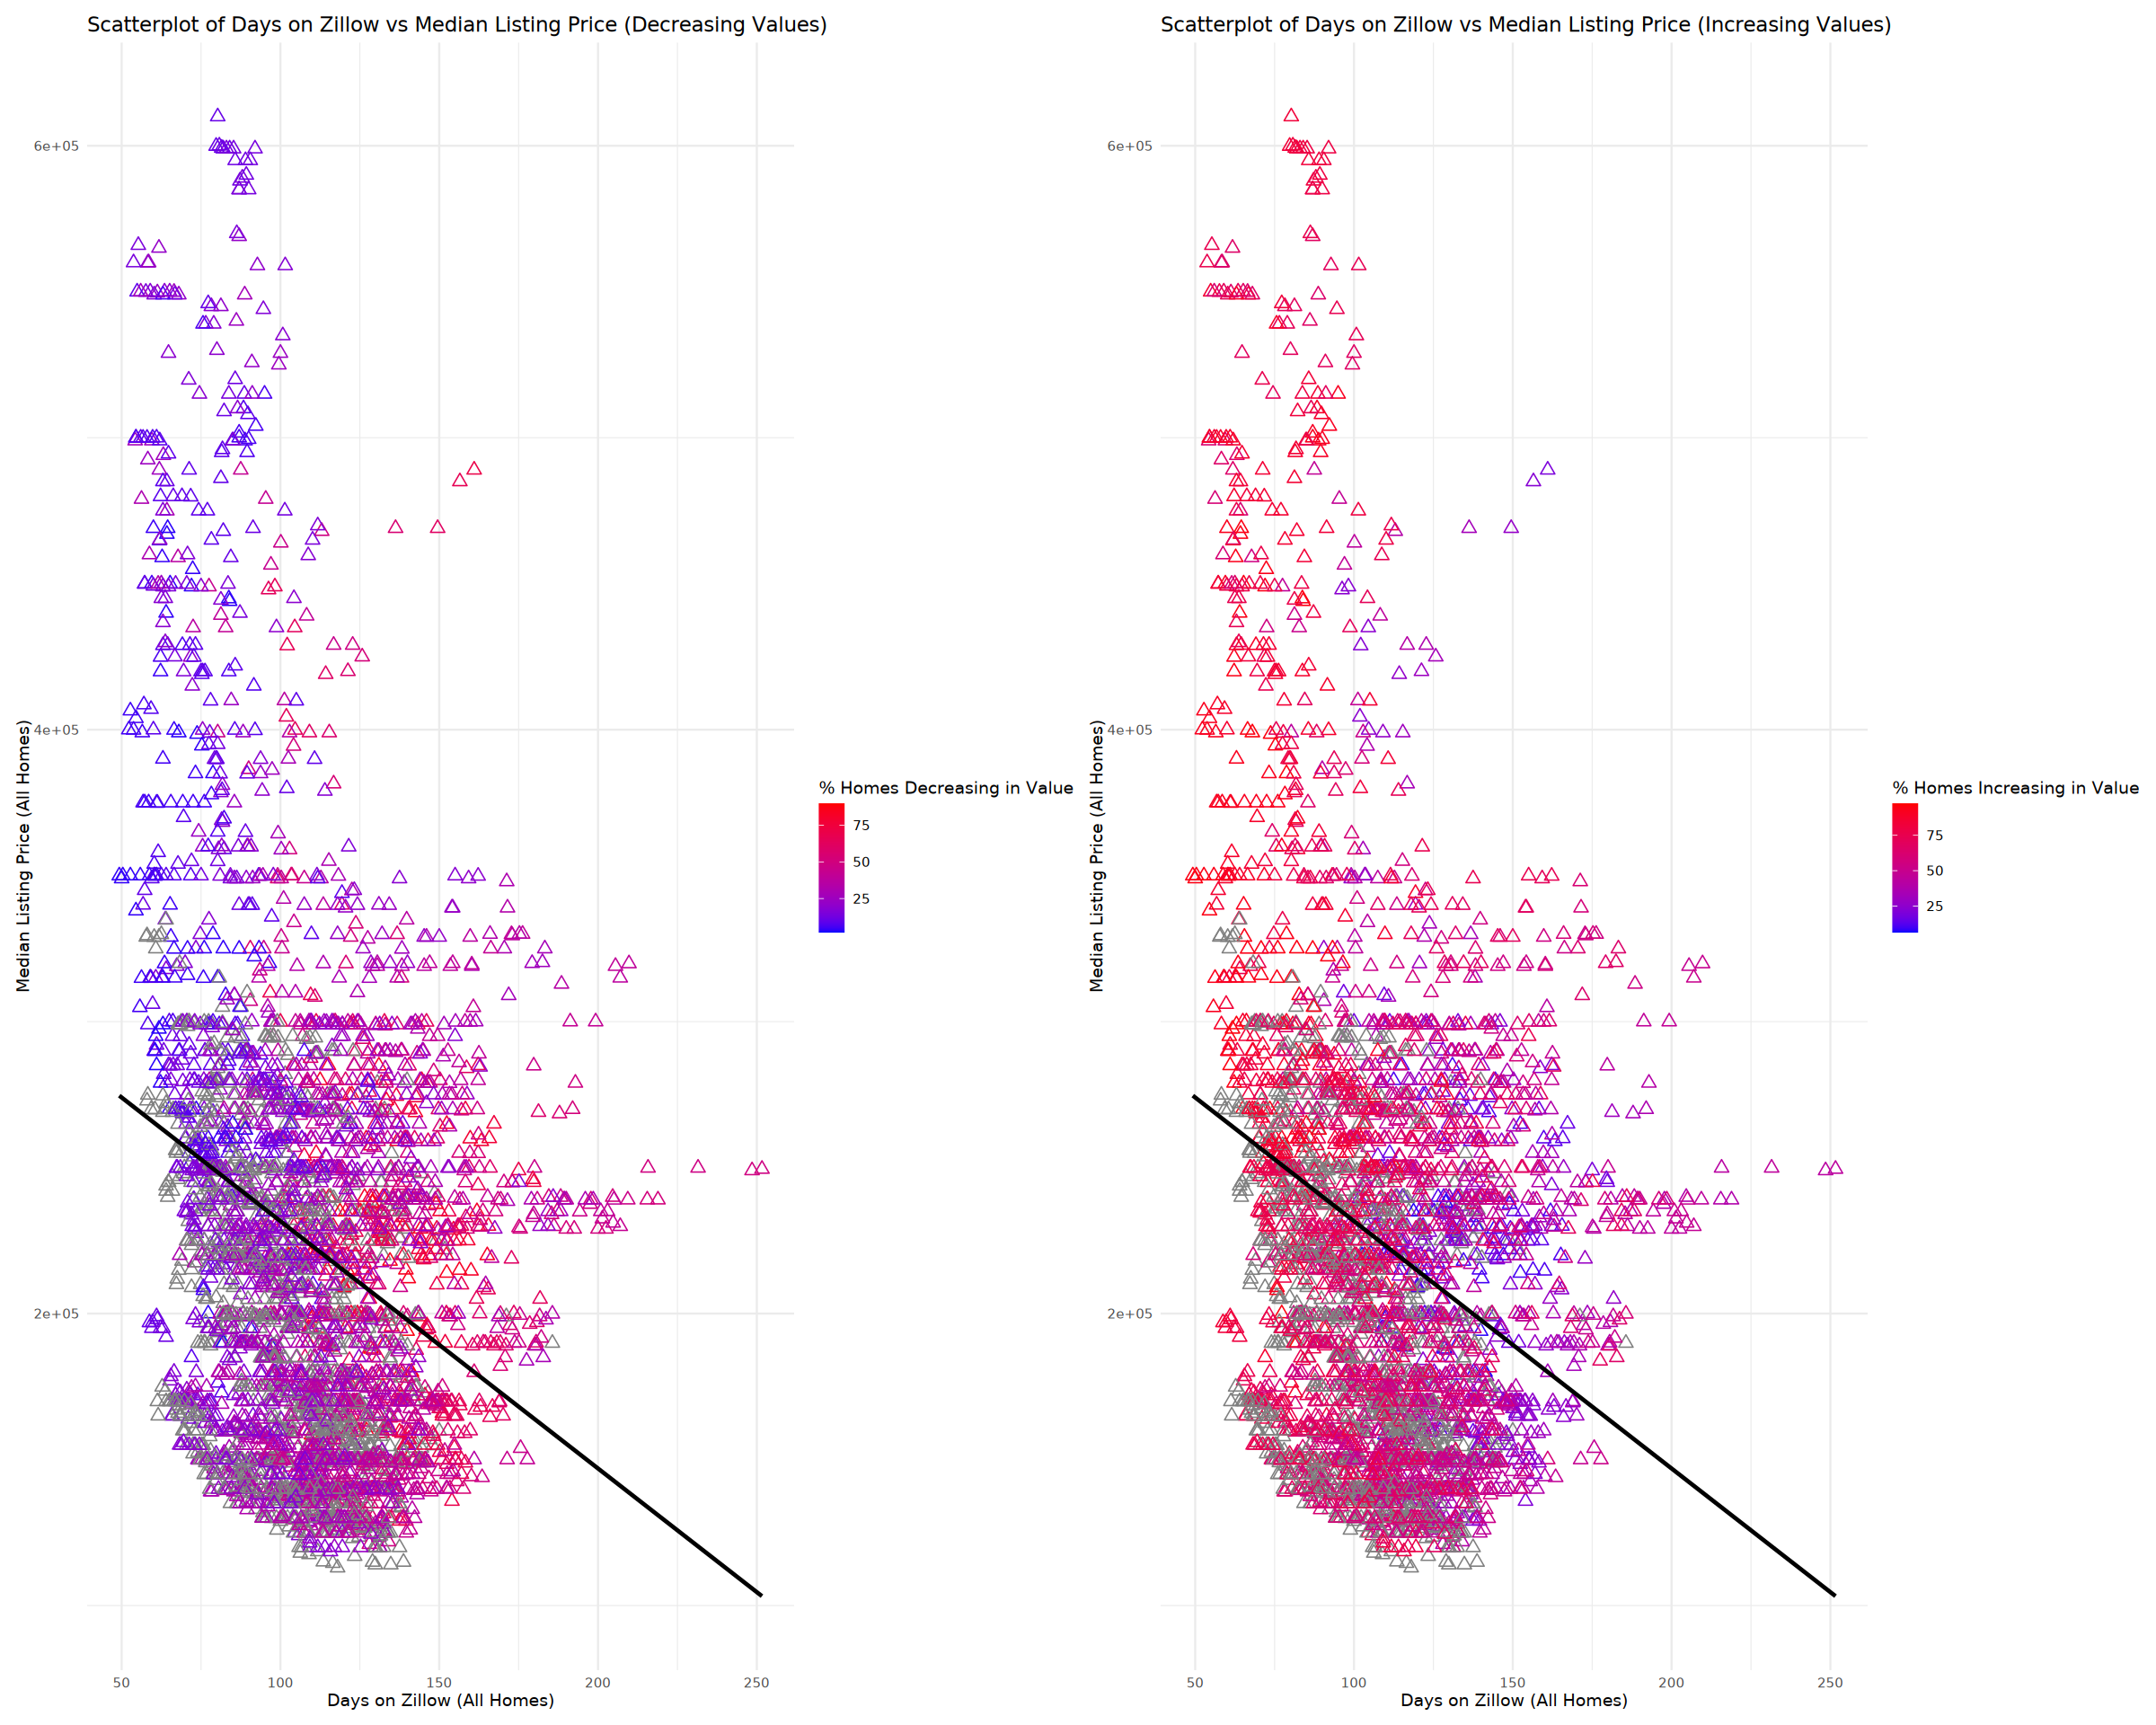

In [49]:
p1 + p2

Combine plots side by side using patchwork

Interpretation:
1. The scatterplots show that homes with longer days on Zillow tend to have lower median listing prices, but there is significant spread (many outliers with high price and long days).
2. The trendline (linear model) confirms a general negative relationship between days on market and price.
3. Coloring by % homes decreasing or increasing shows that higher percentages of decreasing-value homes tend to cluster where listing prices are higher, suggesting price adjustments may be occurring.
4. The plots also highlight clusters of homes that sell quickly at low prices, and a few extreme outliers.

## Question 5

In [53]:
library(lubridate)
zillow_cleaned$Date <- as.Date(zillow_cleaned$Date)

Using the lubridate library, convert Date column to Date type

In [57]:
selected_regions <- c("Indiana", "Tennessee", "Utah", "NewHampshire")

zillow_grouped_small <- zillow_cleaned %>%
  filter(RegionName %in% selected_regions,
         !is.na(MedianListingPrice_AllHomes)) %>% 
  group_by(Date, RegionName) %>%
  # Compute average price per date and region
  summarise(avg_price = mean(MedianListingPrice_AllHomes), .groups = "drop")

Filter data for selected regions and remove NA values in MedianListingPrice_AllHomes

In [58]:
head(zillow_grouped_small)

Date,RegionName,avg_price
<date>,<chr>,<dbl>
2010-01-31,Indiana,124900
2010-01-31,NewHampshire,249000
2010-01-31,Tennessee,159800
2010-02-28,Indiana,125000
2010-02-28,NewHampshire,239999
2010-02-28,Tennessee,159000


Explanation:
NA values were removed using !is.na(). This ensures that the mean calculation for avg_price does not include missing values and all plotted points represent real data.

In [60]:
p <- ggplot(zillow_grouped_small, 
            aes(x = Date, y = avg_price, color = RegionName, group = RegionName)) +
  geom_line(linewidth = 1) +  # Draw lines for each region
  labs(title = "Average Median Listing Price Over Time",
       x = "Date",
       y = "Average Median Listing Price ($)",
       color = "Region") +
  theme_minimal()

Line plot for selected regions

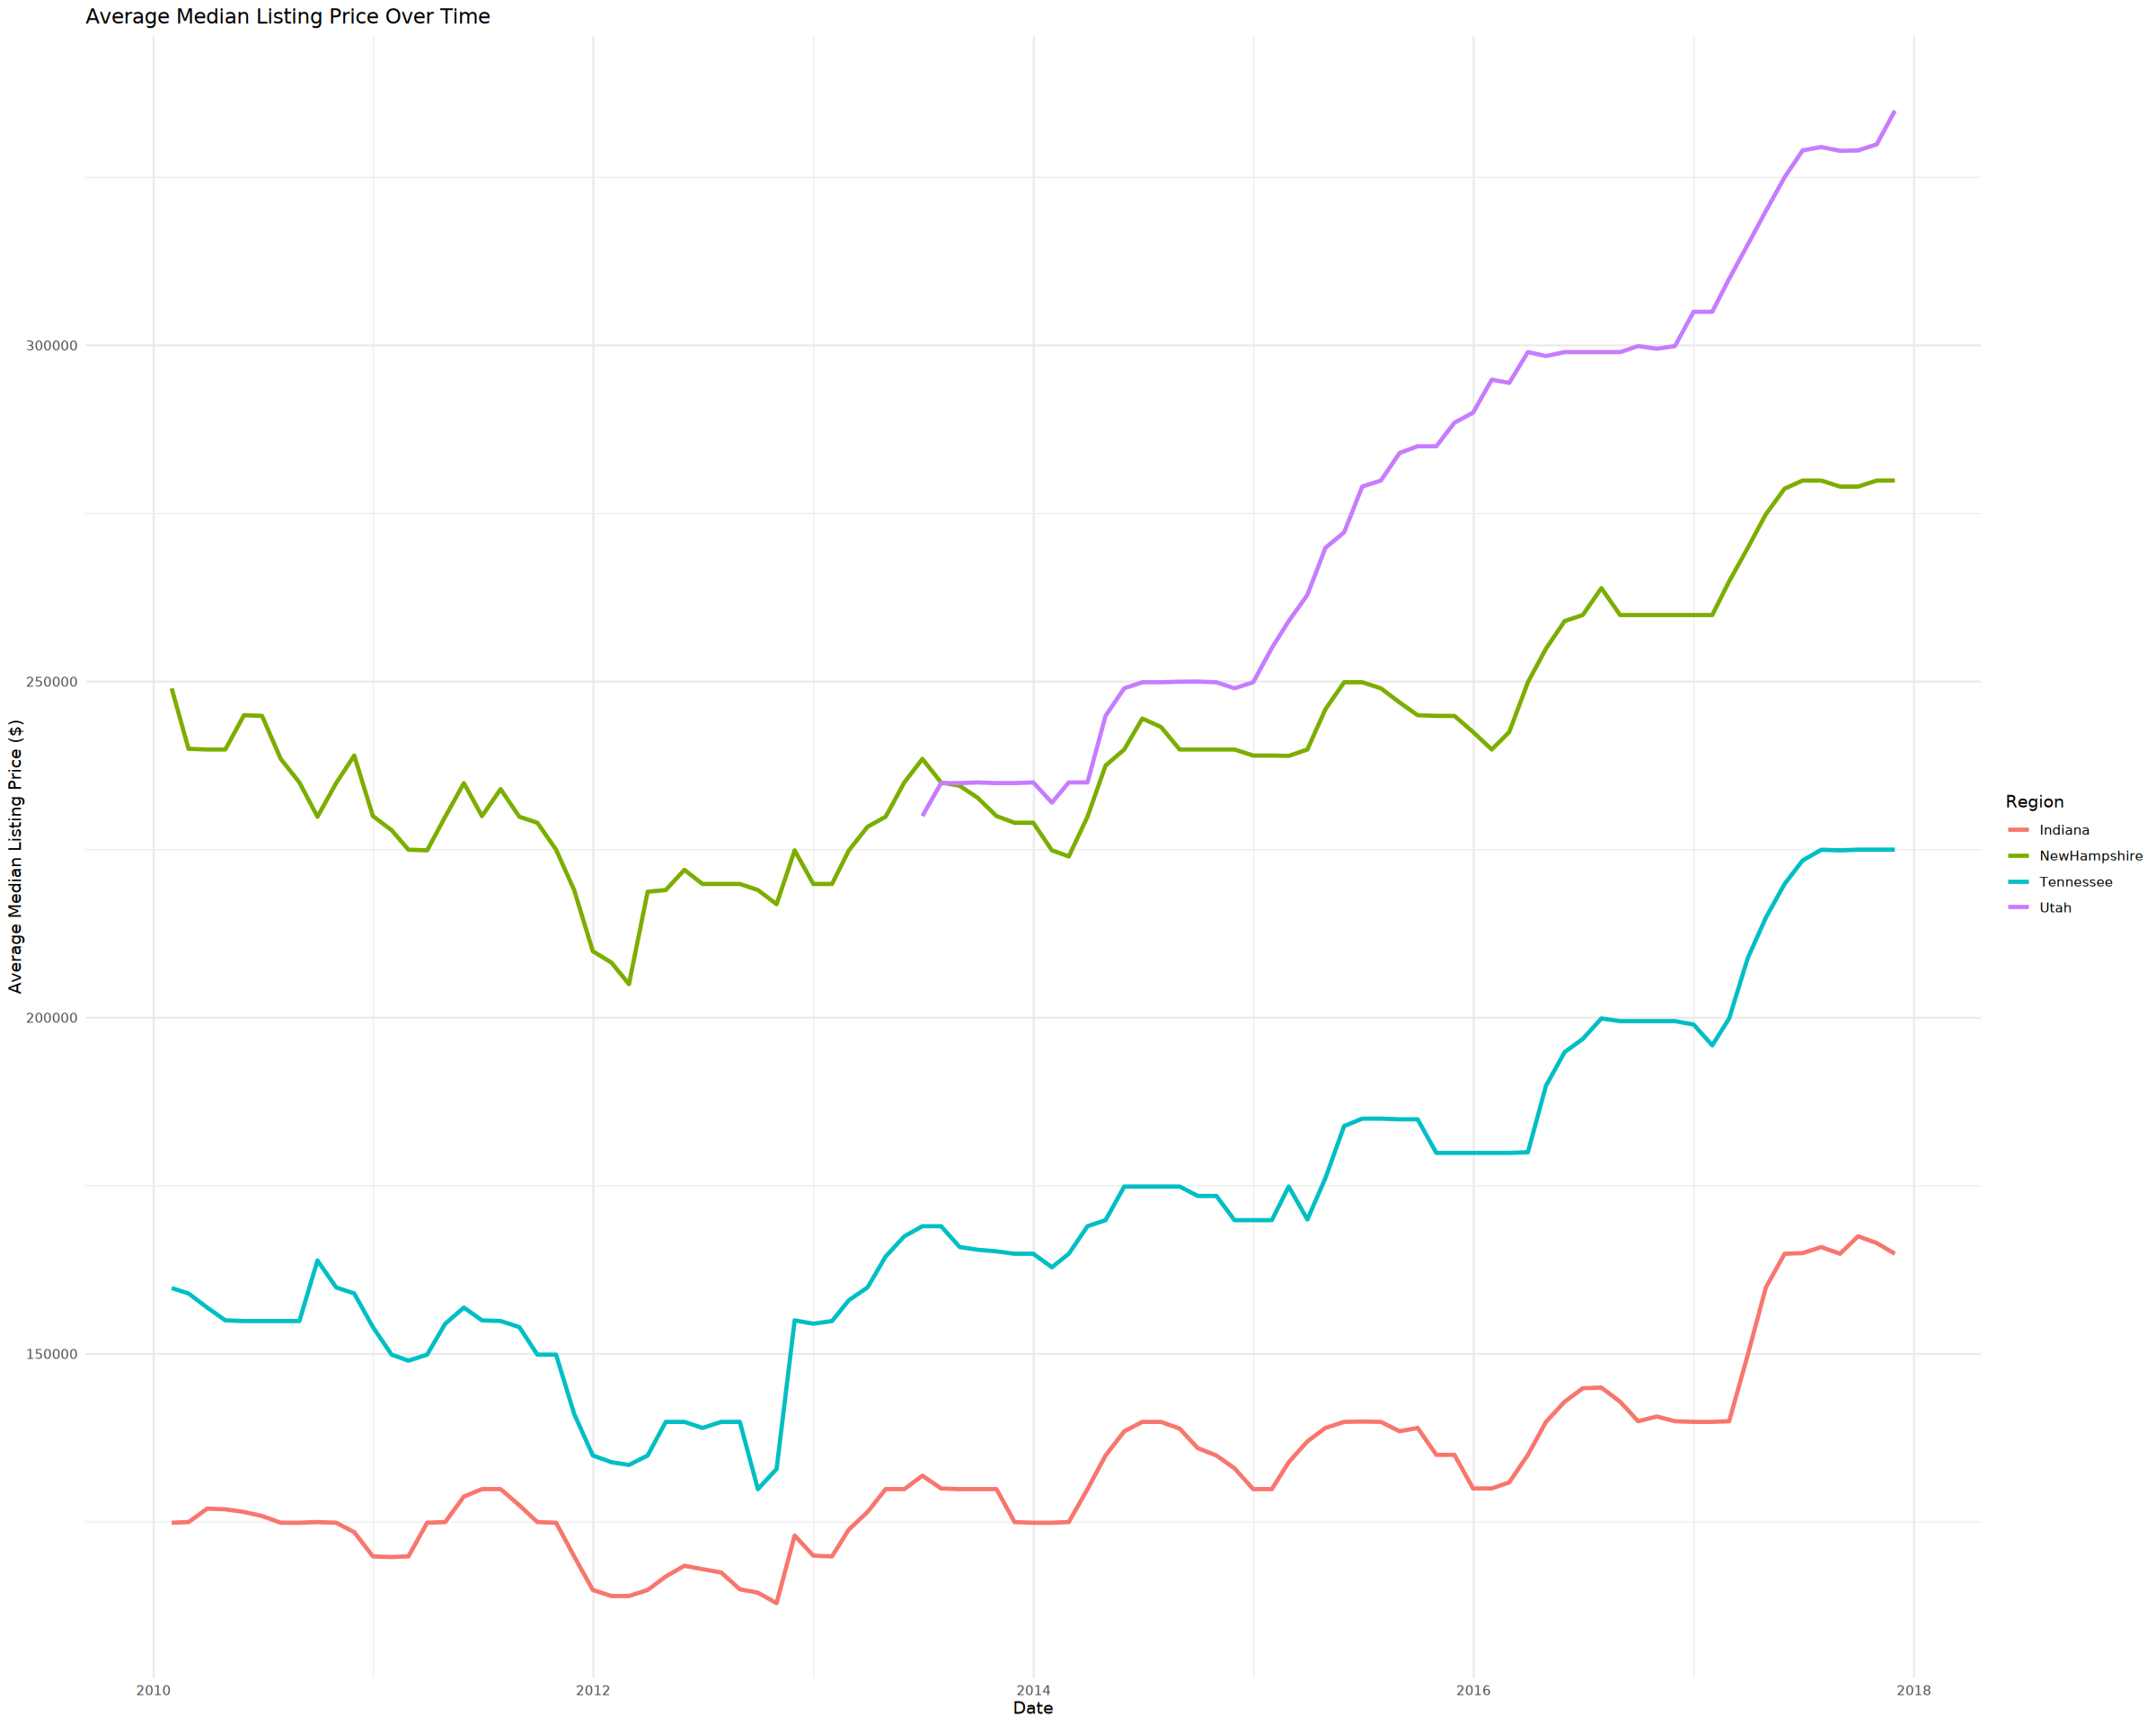

In [61]:
p

In [62]:
more_selected_regions <- c("California", "Delaware", "Florida", "Alaska")

zillow_grouped_more <- zillow_cleaned %>%
  filter(RegionName %in% more_selected_regions,
         !is.na(MedianListingPrice_AllHomes)) %>%
  group_by(Date, RegionName) %>%
  summarise(avg_price = mean(MedianListingPrice_AllHomes), .groups = "drop")

Add additional regions and prepare their data

In [64]:
p_final <- p +
  geom_line(data = zillow_grouped_more, aes(x = Date, y = avg_price, color = RegionName, group = RegionName), size = 1, linetype = "dashed")

Add lines for additional regions to the existing plot

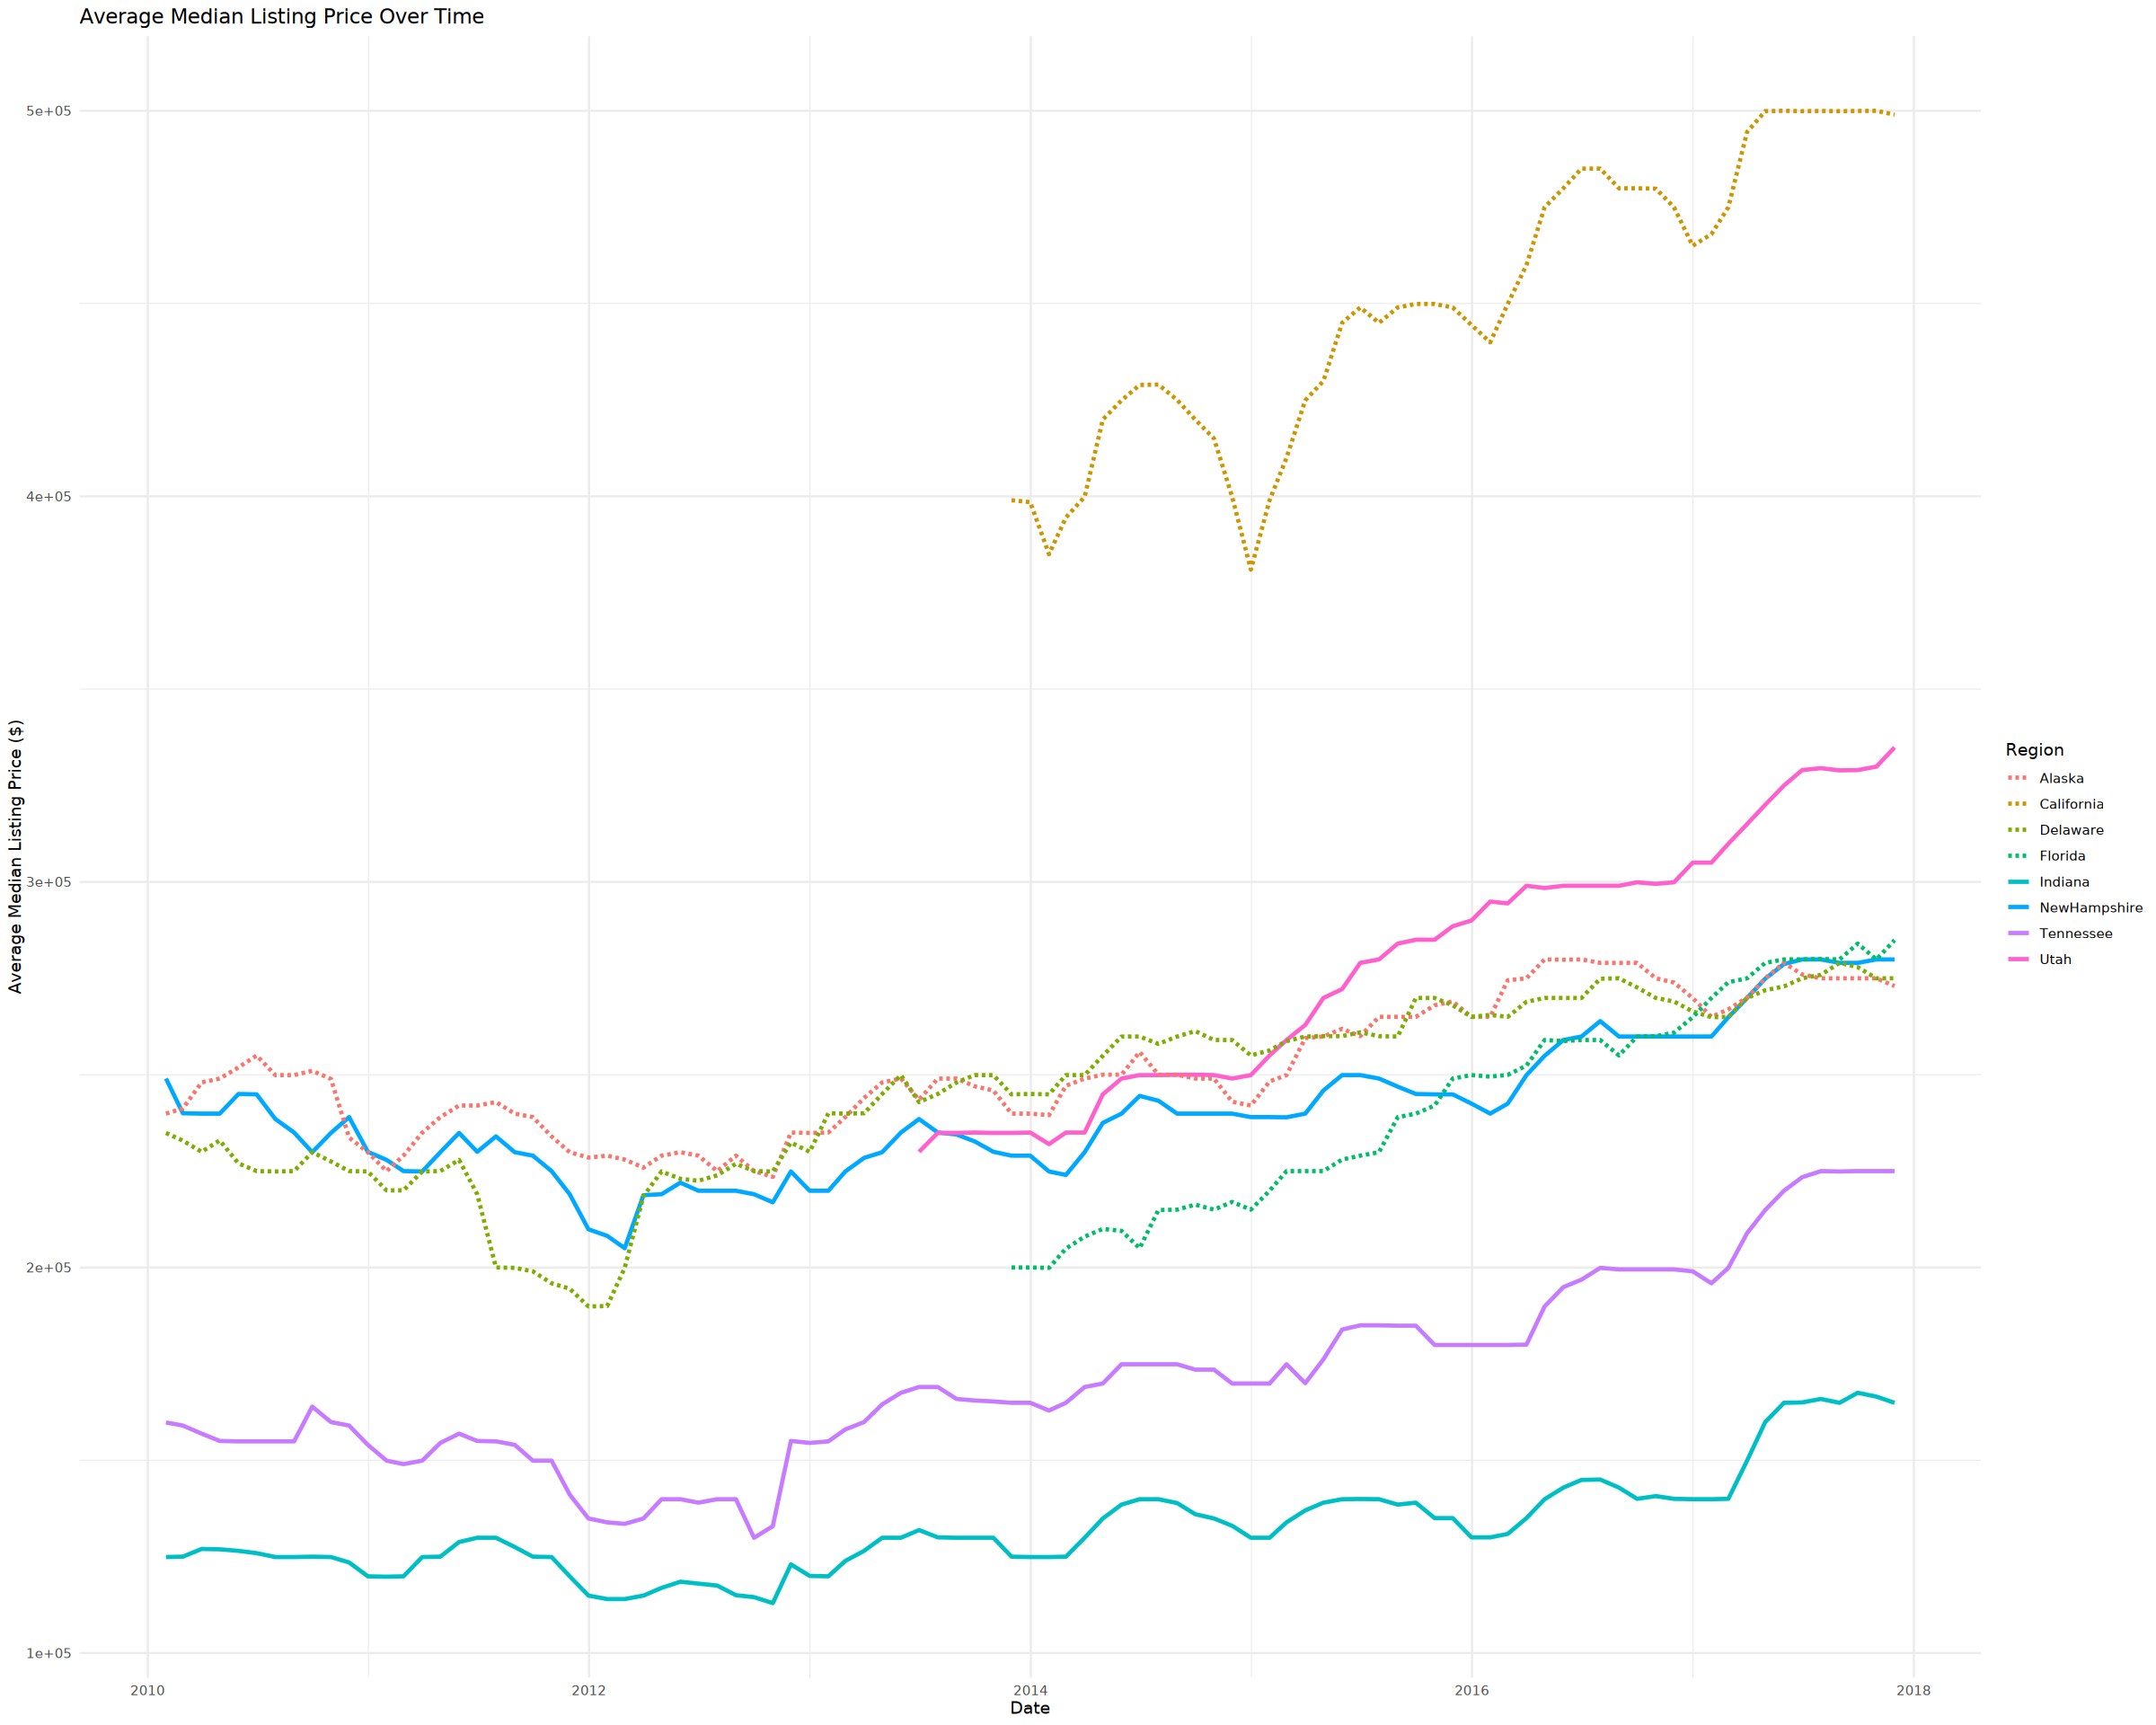

In [65]:
p_final

Interpretation:
- The line plot shows trends in average median listing prices over time for all selected regions.
- Some states show consistent upward trends (e.g., California, Florida), while others may fluctuate more.
- Dashed lines for additional regions allow comparison; differences in slope indicate differing market growth rates.
- The plot highlights seasonal or long-term trends in housing prices and can reveal outliers or sudden spikes in certain states.

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
